# Project 2 - Utilizing hospital beds during epidemics

In [1]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
### Define functions for arrival rates
def arr_rate1(t):
    return -(1/3650)*t**2 + (1/10)*t

def arr_rate2(t):
    return (1/5)*( -(1/3650)*t**2 + (1/10)*t )

def arr_rate3(t):
    return 6

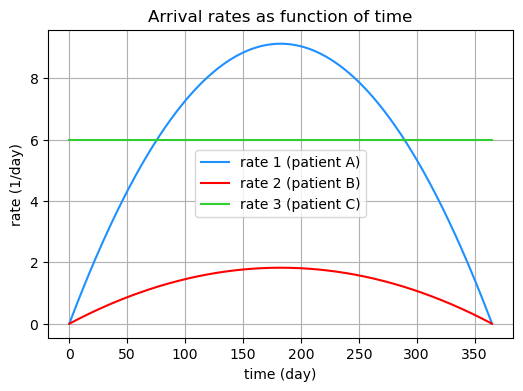

In [3]:
### Viasualise arrival rates 
tgrid = np.linspace(0,365, num=1000)

fig, ax = plt.subplots(figsize=(6,4))

ax.plot(
    tgrid,
    arr_rate1(tgrid),
    label='rate 1 (patient A)',
    color='dodgerblue'
)
ax.plot(
    tgrid,
    arr_rate2(tgrid),
    label='rate 2 (patient B)',
    color='red'
)
ax.plot(
    tgrid,
    [arr_rate3(t) for t in tgrid],
    label='rate 3 (patient C)',
    color='limegreen'
)

plt.xlabel("time (day)")
plt.ylabel("rate (1/day)")
plt.title('Arrival rates as function of time')
plt.legend()
plt.grid()
plt.show()

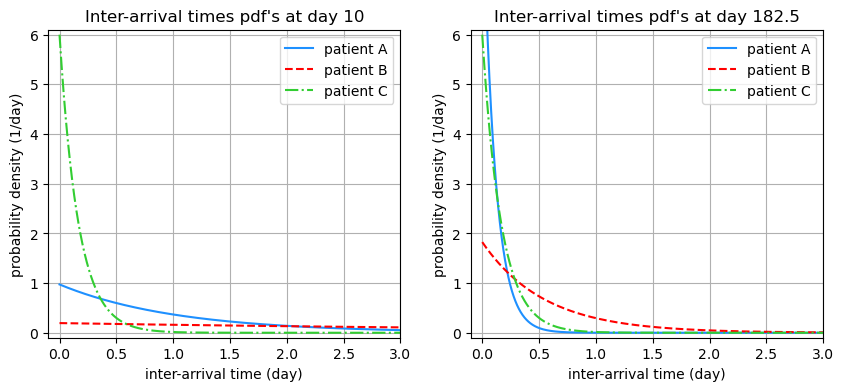

In [15]:
### Visualise distribution that interarrival times are drawn from at specific 
xgrid = np.linspace(0,4, num=5000)

day1 = 10
day2 = 182.5

expA_vals1 = sp.stats.expon.pdf(x=xgrid, scale=1/arr_rate1(day1))
expB_vals1 = sp.stats.expon.pdf(x=xgrid, scale=1/arr_rate2(day1))
expA_vals2 = sp.stats.expon.pdf(x=xgrid, scale=1/arr_rate1(day2))
expB_vals2 = sp.stats.expon.pdf(x=xgrid, scale=1/arr_rate2(day2))

expC_vals = sp.stats.expon.pdf(x=xgrid, scale=1/arr_rate3(day1))

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].plot(
    xgrid,
    expA_vals1,
    label='patient A',
    linestyle = 'solid',
    color='dodgerblue'
)
ax[0].plot(
    xgrid,
    expB_vals1,
    label='patient B',
    linestyle='dashed',
    color='red'
)

ax[0].plot(
    xgrid,
    expC_vals,
    label='patient C',
    linestyle='dashdot',
    color='limegreen'
)

ax[1].plot(
    xgrid,
    expA_vals2,
    label='patient A',
    linestyle='solid',
    color='dodgerblue'
)
ax[1].plot(
    xgrid,
    expB_vals2,
    label='patient B',
    linestyle='dashed',
    color='red'
)
ax[1].plot(
    xgrid,
    expC_vals,
    label='patient C',
    linestyle='dashdot',
    color='limegreen'
)



ax[0].set_xlabel("inter-arrival time (day)")
ax[0].set_ylabel("probability density (1/day)")
ax[0].set_title(f"Inter-arrival times pdf's at day {day1}")
ax[0].legend()
ax[0].grid()
ax[0].set_ylim(-0.1,6.1)
ax[0].set_xlim(-0.1,3)


ax[1].set_xlabel("inter-arrival time (day)")
ax[1].set_ylabel("probability density (1/day)")
ax[1].set_title(f"Inter-arrival times pdf's at day {day2:.1f}")
ax[1].legend()
ax[1].grid()
ax[1].set_ylim(-0.1,6.1)
ax[1].set_xlim(-0.1,3)


plt.show()

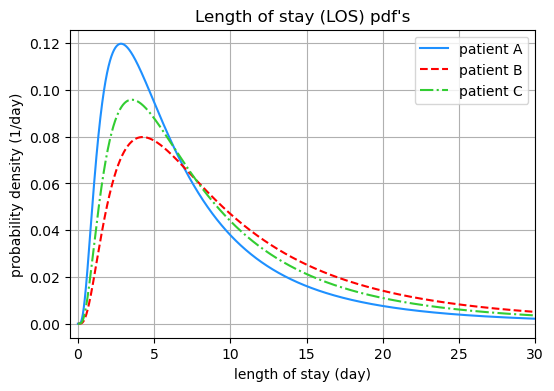

In [17]:
### Making plots for LOS distributions
# Parameters for the distributions
mu_LN_A = np.log(4*np.sqrt(2))
sig2_LN_A = np.log(2)
mu_LN_B = np.log(6*np.sqrt(2))
sig2_LN_B = np.log(2)
mu_LN_C = np.log(5*np.sqrt(2))
sig2_LN_C = np.log(2)
lamb_exp_A = 1/8
lamb_exp_B = 1/12
lamb_exp_C = 1/10

xgrid = np.linspace(0,40, num=5000)
logA_vals = sp.stats.lognorm.pdf(x=xgrid, s=np.sqrt(sig2_LN_A), scale=np.exp(mu_LN_A))
logB_vals = sp.stats.lognorm.pdf(x=xgrid, s=np.sqrt(sig2_LN_B), scale=np.exp(mu_LN_B))
logC_vals = sp.stats.lognorm.pdf(x=xgrid, s=np.sqrt(sig2_LN_C), scale=np.exp(mu_LN_C))


fig, ax = plt.subplots(figsize=(6,4))

ax.plot(
    xgrid,
    logA_vals,
    label='patient A',
    color='dodgerblue'
)
ax.plot(
    xgrid,
    logB_vals,
    label='patient B',
    color='red',
    linestyle='dashed'
)
ax.plot(
    xgrid,
    logC_vals,
    label='patient C',
    color='limegreen',
    linestyle='dashdot'
)


plt.xlabel("length of stay (day)")
plt.ylabel("probability density (1/day)")
plt.title("Length of stay (LOS) pdf's")
plt.xlim(-0.5,30)
plt.legend()
plt.grid()
plt.show()


## Convert previous code to functions, to make sensitivity analysis

In [27]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

seed_all = 42 #choose seed 42 by default

In [28]:
### Define functions for arrival rates
def arr_rate1(t):
    return -(1/3650)*t**2 + (1/10)*t

def arr_rate2(t):
    return (1/5)*( -(1/3650)*t**2 + (1/10)*t )

def arr_rate3(t):
    return 6

In [29]:
### FUNCTION FOR ARRIVAL + LOS TIMES
### Define functions for arrival rates
def generate_arrival_LOS_times( 
        arr_rate1=arr_rate1, 
        arr_rate2=arr_rate2, 
        arr_rate3=arr_rate3,
        LOS_dist = 'lognormal',
        mu_LN_A = np.log(4*np.sqrt(2)),
        sig2_LN_A = np.log(2),
        mu_LN_B = np.log(6*np.sqrt(2)),
        sig2_LN_B = np.log(2),
        mu_LN_C = np.log(5*np.sqrt(2)),
        sig2_LN_C = np.log(2),
        lamb_exp_A = 1/8,
        lamb_exp_B = 1/12,
        lamb_exp_C = 1/10):
    
    #Initialise lists with possible arival times for each patient
    times_A = []
    times_B = []
    times_C = []

    #Loops for creating arrival times for one year:
    T_max = 365 #max time

    # A patients
    t = 0.0 #current time
    lamb0_1 = arr_rate1(T_max/2) #Determine upper bound as maximum (at t=t_max/2, since parabola)
    while t <= T_max:
        t_inter = sp.stats.expon.rvs(scale=1/lamb0_1)
        t += t_inter
        if t <= T_max:
            times_A.append(t) #Append cumulative time

    #B patiens
    t = 0.0 #current time
    lamb0_2 = arr_rate2(T_max/2) #Determine upper bound as maximum (at t=t_max/2, since parabola)
    while t <= T_max:
        t_inter = sp.stats.expon.rvs(scale=1/lamb0_2)
        t += t_inter
        if t <= T_max:
            times_B.append(t) #Append cumulative time

    #C patients 
    t = 0.0 #current time
    lamb3 = arr_rate3(T_max/2) #Determine true rate
    while t <= T_max:
        t_inter = sp.stats.expon.rvs(scale=1/lamb3)
        t += t_inter
        if t <= T_max:
            times_C.append(t) #Append cumulative time

    ### Correcting A and B with time-dependent lambda by rejection sampling
    arrivals_A = []
    arrivals_B = []
    arrivals_C = times_C.copy()

    #For A patients
    for t in times_A:
        alpha = arr_rate1(t)/lamb0_1
        U = sp.stats.uniform.rvs()
        if U < alpha:
            arrivals_A.append(t)

    #For B patients
    for t in times_B:
        alpha = arr_rate2(t)/lamb0_2
        U = sp.stats.uniform.rvs()
        if U < alpha:
            arrivals_B.append(t)

    # Combine into one list, as tuples carrying time and patient type
    arrivals_all = []
    arrivals_all += [(t, "A") for t in arrivals_A]
    arrivals_all += [(t, "B") for t in arrivals_B]
    arrivals_all += [(t, "C") for t in arrivals_C]

    ### Create samples for LOS times (only used if patient gets admitted to hospital)
    if LOS_dist == 'lognormal':
        LOS_A = sp.stats.lognorm.rvs(s=np.sqrt(sig2_LN_A), scale=np.exp(mu_LN_A), size=len(arrivals_A))
        LOS_B = sp.stats.lognorm.rvs(s=np.sqrt(sig2_LN_B), scale=np.exp(mu_LN_B), size=len(arrivals_B))
        LOS_C = sp.stats.lognorm.rvs(s=np.sqrt(sig2_LN_C), scale=np.exp(mu_LN_C), size=len(arrivals_C))
    elif LOS_dist == 'exponential':
        LOS_A = sp.stats.expon.rvs(scale=1/lamb_exp_A, size=len(arrivals_A))
        LOS_B = sp.stats.expon.rvs(scale=1/lamb_exp_B, size=len(arrivals_B))
        LOS_C = sp.stats.expon.rvs(scale=1/lamb_exp_C, size=len(arrivals_C))

    #Combine into one list
    LOS_all = []
    LOS_all += [(t, "A") for t in LOS_A]
    LOS_all += [(t, "B") for t in LOS_B]
    LOS_all += [(t, "C") for t in LOS_C]    

    ### Sort both lists, according to arrival times
    # Combine both lists
    combined = list(zip(arrivals_all, LOS_all))

    # Sort by the first element of the tuple in Arr_time (the number)
    combined.sort(key=lambda x: x[0][0])

    # Unzip back into two lists, and convert back into list of tuple (from tuple of tuples)
    arrivals_all_sorted, LOS_all_sorted = zip(*combined)
    arrivals_all_sorted = list(arrivals_all_sorted)
    LOS_all_sorted = list(LOS_all_sorted)

    return arrivals_all_sorted, LOS_all_sorted

In [39]:
### FUNCTION FOR SIMULATION
def simulate_hospital(
        beds_tot_A, 
        beds_tot_B, 
        beds_tot_C,
        n_BS_samples=1,
        *args,
        **kwargs):

    #Initialise result lists for 'BS' loop
    list_number_of_arrivals_A = []
    list_number_of_arrivals_B = []
    list_number_of_arrivals_C = []
    list_number_of_arrivals_all = []

    list_frac_all_bed_occ_A = []
    list_frac_all_bed_occ_B = []
    list_frac_all_bed_occ_C = []
    list_frac_all_bed_occ_mean = []

    list_num_reloc_A = []
    list_num_reloc_B = []
    list_num_reloc_C = []
    list_num_reloc_all = []

    list_frac_bed_util_A = []
    list_frac_bed_util_B = []
    list_frac_bed_util_C = []
    list_frac_bed_util_mean = []

    #Max time (one year)
    T_max =  365

    print("Beginning BS simulation...")
    ### 'Bootstrap' loop
    for i_boot in range(n_BS_samples):

        #Generate arrival times and LOS-times
        arrivals_all, LOS_all = generate_arrival_LOS_times(*args, **kwargs)

        ### State vaiables
        #time
        t = 0
        
        #Counters for all beds occupied and relocated patients:
        cnt_all_bed_occ_A = 0
        cnt_all_bed_occ_B = 0
        cnt_all_bed_occ_C = 0
        cnt_reloc_A = 0
        cnt_reloc_B = 0
        cnt_reloc_C = 0

        #Departure time from each ward 
        # (also used as "beds in use" variable, by its length)
        depatures_A = []
        depatures_B = []
        depatures_C = []

        #Utilisation time for all beds:
        # counting "bed-time", correspodnding to, how long time each it is used, and then summed for all beds) 
        # will be normalised by 365 days * number of beds
        bed_util_A = 0
        bed_util_B = 0
        bed_util_C = 0

        #Loop over all patients
        for i, (arr_time, type) in enumerate(arrivals_all):

            #update time 
            t = arr_time

            #update depature lists: letting patients leave (keeping only times longer that current time)
            if len(depatures_A) > 0:
                depatures_A = [dep for dep in depatures_A if dep > t]

            if len(depatures_B) > 0:
                depatures_B = [dep for dep in depatures_B if dep > t]

            #update depature lists, keeping only times longer that current time
            if len(depatures_C) > 0:
                depatures_C = [dep for dep in depatures_C if dep > t]
            
            #Try to assign patient to correct ward (first B, then A and C (in arbitrary order))
            #Patient B
            if type == 'B':
                #If ward is not full: admit patient, assign departure time, and add LOS to bed utility time
                if len(depatures_B) < beds_tot_B:
                    los_B = LOS_all[i][0]
                    depatures_B.append(t + los_B)
                    bed_util_B += los_B
                #If ward is full: count full ward and relocated for ward B
                else:
                    cnt_reloc_B += 1

                    #Try in ward A (but assign LOS and bed utility time according to B)
                    if len(depatures_A) < beds_tot_A:
                        los_B = LOS_all[i][0]
                        depatures_A.append(t + los_B)
                        bed_util_A += los_B
                    #else send to other hospital, count full ward and relocation of patient B
                    else:
                        cnt_all_bed_occ_B += 1
                        

            #Patient A
            if type == 'A':
                #If ward is not full: admit patient, assign departure time, and add LOS to bed utility time
                if len(depatures_A) < beds_tot_A:
                    los_A = LOS_all[i][0]
                    depatures_A.append(t + los_A)
                    bed_util_A += los_A
                #If ward is full: count full ward and reloc 
                else:
                    cnt_all_bed_occ_A += 1
                    cnt_reloc_A += 1

            #Patient C
            if type == 'C':
                #If ward is not full: admit patient, assign departure time, and add LOS to bed utility time
                if len(depatures_C) < beds_tot_C:
                    los_C = LOS_all[i][0]
                    depatures_C.append(t + los_C)
                    bed_util_C += los_C
                #If ward is full: count full ward and reloc 
                else:
                    cnt_all_bed_occ_C += 1
                    cnt_reloc_C += 1    

        ### Compute results:
        n_arrived_all = len(arrivals_all)
        n_arrived_A = sum(1 for let in arrivals_all if let[1] == 'A')
        n_arrived_B = sum(1 for let in arrivals_all if let[1] == 'B')
        n_arrived_C = sum(1 for let in arrivals_all if let[1] == 'C')

        #ward rejecting patient upon arrival due to capacity limit
        frac_all_bed_occ_A = cnt_all_bed_occ_A/n_arrived_A
        frac_all_bed_occ_B = cnt_all_bed_occ_B/n_arrived_B
        frac_all_bed_occ_C = cnt_all_bed_occ_C/n_arrived_C

        #patient being relocated out of hospital (i.e. excluding internal relocation)
        num_reloc_all = (cnt_reloc_A+cnt_reloc_B+cnt_reloc_C)

        #fraction of available bed time used for each ward
        frac_bed_util_A = bed_util_A / (beds_tot_A*T_max)
        frac_bed_util_B = bed_util_B / (beds_tot_B*T_max)
        frac_bed_util_C = bed_util_C / (beds_tot_C*T_max)

        ### Append BS results
        list_frac_all_bed_occ_A.append(frac_all_bed_occ_A)
        list_frac_all_bed_occ_B.append(frac_all_bed_occ_B)
        list_frac_all_bed_occ_C.append(frac_all_bed_occ_C)
        list_frac_all_bed_occ_mean.append(np.average(a=[frac_all_bed_occ_A, frac_all_bed_occ_B, frac_all_bed_occ_C],
                                                     weights=[n_arrived_A, n_arrived_B, n_arrived_C]))

        list_num_reloc_A.append(cnt_reloc_A)
        list_num_reloc_B.append(cnt_reloc_B)
        list_num_reloc_C.append(cnt_reloc_C)
        list_num_reloc_all.append(num_reloc_all)

        list_number_of_arrivals_A.append(n_arrived_A)
        list_number_of_arrivals_B.append(n_arrived_B)
        list_number_of_arrivals_C.append(n_arrived_C)
        list_number_of_arrivals_all.append(n_arrived_all)

        list_frac_bed_util_A.append(frac_bed_util_A)
        list_frac_bed_util_B.append(frac_bed_util_B)
        list_frac_bed_util_C.append(frac_bed_util_C)
        list_frac_bed_util_mean.append(np.average(a=[frac_bed_util_A,frac_bed_util_B,frac_bed_util_C],
                                                  weights=[beds_tot_A, beds_tot_B, beds_tot_C]))
        
        #Status 
        if (i_boot + 1) % 10 == 0:
            print(f"BS iteration {i_boot+1}")

    ### Compute best estimates as mean, and CIs based on t-distribution
    conf = 0.95
    res_frac_all_bed_occ_A = np.mean(list_frac_all_bed_occ_A)
    sem_frac_all_bed_occ_A = sp.stats.sem(a=list_frac_all_bed_occ_A, ddof=1)
    ci_frac_all_bed_occ_A = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_frac_all_bed_occ_A,
        scale = sem_frac_all_bed_occ_A)

    res_frac_all_bed_occ_B = np.mean(list_frac_all_bed_occ_B)
    sem_frac_all_bed_occ_B = sp.stats.sem(a=list_frac_all_bed_occ_B, ddof=1)
    ci_frac_all_bed_occ_B = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_frac_all_bed_occ_B,
        scale = sem_frac_all_bed_occ_B)
    
    res_frac_all_bed_occ_C = np.mean(list_frac_all_bed_occ_C)
    sem_frac_all_bed_occ_C = sp.stats.sem(a=list_frac_all_bed_occ_C, ddof=1)
    ci_frac_all_bed_occ_C = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_frac_all_bed_occ_C,
        scale = sem_frac_all_bed_occ_C)
    
    res_frac_all_bed_occ_mean = np.mean(list_frac_all_bed_occ_mean)
    sem_frac_all_bed_occ_mean = sp.stats.sem(a=list_frac_all_bed_occ_mean, ddof=1)
    ci_frac_all_bed_occ_mean = sp.stats.t.interval(
        confidence=conf, df = n_BS_samples-1,
        loc = res_frac_all_bed_occ_mean,
        scale = sem_frac_all_bed_occ_mean)

    res_num_reloc_A = np.mean(list_num_reloc_A)
    sem_num_reloc_A = sp.stats.sem(a=list_num_reloc_A, ddof=1)
    ci_num_reloc_A = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_num_reloc_A,
        scale = sem_num_reloc_A)

    res_num_reloc_B = np.mean(list_num_reloc_B)
    sem_num_reloc_B = sp.stats.sem(a=list_num_reloc_B, ddof=1)
    ci_num_reloc_B = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_num_reloc_B,
        scale = sem_num_reloc_B)

    res_num_reloc_C = np.mean(list_num_reloc_C)
    sem_num_reloc_C = sp.stats.sem(a=list_num_reloc_C, ddof=1)
    ci_num_reloc_C = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_num_reloc_C,
        scale = sem_num_reloc_C)
    
    res_num_reloc_all = np.mean(list_num_reloc_all)
    sem_num_reloc_all = sp.stats.sem(a=list_num_reloc_all, ddof=1)
    ci_num_reloc_all = sp.stats.t.interval(
        confidence=conf, df = n_BS_samples-1,
        loc = res_num_reloc_all,
        scale = sem_num_reloc_all)

    res_frac_bed_util_A = np.mean(list_frac_bed_util_A)
    sem_frac_bed_util_A = sp.stats.sem(a=list_frac_bed_util_A, ddof=1)
    ci_frac_bed_util_A = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_frac_bed_util_A,
        scale = sem_frac_bed_util_A)

    res_frac_bed_util_B = np.mean(list_frac_bed_util_B)
    sem_frac_bed_util_B = sp.stats.sem(a=list_frac_bed_util_B, ddof=1)
    ci_frac_bed_util_B = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_frac_bed_util_B,
        scale = sem_frac_bed_util_B)
    
    res_frac_bed_util_C = np.mean(list_frac_bed_util_C)
    sem_frac_bed_util_C = sp.stats.sem(a=list_frac_bed_util_C, ddof=1)
    ci_frac_bed_util_C = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_frac_bed_util_C,
        scale = sem_frac_bed_util_C)
    
    res_frac_bed_util_mean = np.mean(list_frac_bed_util_mean)
    sem_frac_bed_util_mean = sp.stats.sem(a=list_frac_bed_util_mean, ddof=1)
    ci_frac_bed_util_mean = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_frac_bed_util_mean,
        scale = sem_frac_bed_util_mean)
    
    res_numer_of_arrivals_A = np.mean(list_number_of_arrivals_A)
    sem_numer_of_arrivals_A = sp.stats.sem(a=list_number_of_arrivals_A, ddof=1)
    ci_numer_of_arrivals_A = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_numer_of_arrivals_A,
        scale = sem_numer_of_arrivals_A)

    res_numer_of_arrivals_B = np.mean(list_number_of_arrivals_B)
    sem_numer_of_arrivals_B = sp.stats.sem(a=list_number_of_arrivals_B, ddof=1)
    ci_numer_of_arrivals_B = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_numer_of_arrivals_B,
        scale = sem_numer_of_arrivals_B)
    
    res_numer_of_arrivals_C = np.mean(list_number_of_arrivals_C)
    sem_numer_of_arrivals_C = sp.stats.sem(a=list_number_of_arrivals_C, ddof=1)
    ci_numer_of_arrivals_C = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_numer_of_arrivals_C,
        scale = sem_numer_of_arrivals_C)

    res_numer_of_arrivals_all = np.mean(list_number_of_arrivals_all)
    sem_numer_of_arrivals_all = sp.stats.sem(a=list_number_of_arrivals_all, ddof=1)
    ci_numer_of_arrivals_all = sp.stats.t.interval(
        confidence=conf, df=n_BS_samples-1,
        loc = res_numer_of_arrivals_all,
        scale = sem_numer_of_arrivals_all)

    print("BS simulation done!")

    return {
        "res_numer_of_arrivals_A": res_numer_of_arrivals_A,
        "ci_numer_of_arrivals_A": ci_numer_of_arrivals_A,
        "res_numer_of_arrivals_B": res_numer_of_arrivals_B,
        "ci_numer_of_arrivals_B": ci_numer_of_arrivals_B,
        "res_numer_of_arrivals_C": res_numer_of_arrivals_C,
        "ci_numer_of_arrivals_C": ci_numer_of_arrivals_C,
        "res_numer_of_arrivals_all": res_numer_of_arrivals_all,
        "ci_numer_of_arrivals_all": ci_numer_of_arrivals_all,
        "res_frac_all_bed_occ_A": res_frac_all_bed_occ_A,
        "ci_frac_all_bed_occ_A": ci_frac_all_bed_occ_A,
        "res_frac_all_bed_occ_B": res_frac_all_bed_occ_B,
        "ci_frac_all_bed_occ_B": ci_frac_all_bed_occ_B,
        "res_frac_all_bed_occ_C": res_frac_all_bed_occ_C,
        "ci_frac_all_bed_occ_C": ci_frac_all_bed_occ_C,
        "res_frac_all_bed_occ_mean": res_frac_all_bed_occ_mean,
        "ci_frac_all_bed_occ_mean": ci_frac_all_bed_occ_mean,
        "res_num_reloc_A": res_num_reloc_A,
        "ci_num_reloc_A": ci_num_reloc_A,
        "res_num_reloc_B": res_num_reloc_B,
        "ci_num_reloc_B": ci_num_reloc_B,
        "res_num_reloc_C": res_num_reloc_C,
        "ci_num_reloc_C": ci_num_reloc_C,
        "res_num_reloc_all": res_num_reloc_all,
        "ci_num_reloc_all": ci_num_reloc_all,
        "res_frac_bed_util_A": res_frac_bed_util_A,
        "ci_frac_bed_util_A": ci_frac_bed_util_A,
        "res_frac_bed_util_B": res_frac_bed_util_B,
        "ci_frac_bed_util_B": ci_frac_bed_util_B,
        "res_frac_bed_util_C": res_frac_bed_util_C,
        "ci_frac_bed_util_C": ci_frac_bed_util_C,
        "res_frac_bed_util_mean": res_frac_bed_util_mean,
        "ci_frac_bed_util_mean": ci_frac_bed_util_mean
    }

In [40]:
### For first (stupid) bed distribution
from pprint import pprint
np.random.seed(seed_all)

m_A = 20
m_B = 20
m_C = 35
los_dist = 'lognormal'

results1 = simulate_hospital(
        beds_tot_A=m_A, 
        beds_tot_B=m_B, 
        beds_tot_C=m_C,
        n_BS_samples=100,
        arr_rate1=arr_rate1, 
        arr_rate2=arr_rate2, 
        arr_rate3=arr_rate3,
        LOS_dist = los_dist,
        mu_LN_A = np.log(4*np.sqrt(2)),
        sig2_LN_A = np.log(2),
        mu_LN_B = np.log(6*np.sqrt(2)),
        sig2_LN_B = np.log(2),
        mu_LN_C = np.log(5*np.sqrt(2)),
        sig2_LN_C = np.log(2),
        lamb_exp_A = 1/8,
        lamb_exp_B = 1/12,
        lamb_exp_C = 1/10)

Beginning BS simulation...
BS iteration 10
BS iteration 20
BS iteration 30
BS iteration 40
BS iteration 50
BS iteration 60
BS iteration 70
BS iteration 80
BS iteration 90
BS iteration 100
BS simulation done!


In [41]:
print("Results!")
print(f"Paramters: m_A={m_A}, m_B={m_B}, m_C={m_C}, LOS dist.: {los_dist}")
pprint(results1)

Results!
Paramters: m_A=20, m_B=20, m_C=35, LOS dist.: lognormal
{'ci_frac_all_bed_occ_A': (0.6371135257183763, 0.642856979846563),
 'ci_frac_all_bed_occ_B': (0.08310709196613676, 0.09272999350825266),
 'ci_frac_all_bed_occ_C': (0.42081384330209015, 0.42891546879859554),
 'ci_frac_all_bed_occ_mean': (0.4901614662372371, 0.49492472140734),
 'ci_frac_bed_util_A': (0.8970873853552618, 0.9015518329994171),
 'ci_frac_bed_util_B': (0.6408034764752171, 0.651633805406606),
 'ci_frac_bed_util_C': (0.9818097781980125, 0.9845173557489898),
 'ci_frac_bed_util_mean': (0.8691769630720239, 0.872729432832978),
 'ci_num_reloc_A': (1410.0016687878722, 1432.5583312121278),
 'ci_num_reloc_B': (49.420312537138095, 55.579687462861905),
 'ci_num_reloc_C': (919.6016265093921, 943.4783734906079),
 'ci_num_reloc_all': (2387.660618213081, 2422.9793817869195),
 'ci_numer_of_arrivals_A': (2210.0369461357504, 2230.3230538642492),
 'ci_numer_of_arrivals_B': (440.20896359864673, 448.3510364013532),
 'ci_numer_of_arri

In [42]:
### For optimised bed distribution

from pprint import pprint
np.random.seed(seed_all)

m_A = 24
m_B = 8
m_C = 43
los_dist = 'lognormal'

results2 = simulate_hospital(
        beds_tot_A=m_A, 
        beds_tot_B=m_B, 
        beds_tot_C=m_C,
        n_BS_samples=100,
        arr_rate1=arr_rate1, 
        arr_rate2=arr_rate2, 
        arr_rate3=arr_rate3,
        LOS_dist = los_dist,
        mu_LN_A = np.log(4*np.sqrt(2)),
        sig2_LN_A = np.log(2),
        mu_LN_B = np.log(6*np.sqrt(2)),
        sig2_LN_B = np.log(2),
        mu_LN_C = np.log(5*np.sqrt(2)),
        sig2_LN_C = np.log(2),
        lamb_exp_A = 1/8,
        lamb_exp_B = 1/12,
        lamb_exp_C = 1/10)

Beginning BS simulation...
BS iteration 10
BS iteration 20
BS iteration 30
BS iteration 40
BS iteration 50
BS iteration 60
BS iteration 70
BS iteration 80
BS iteration 90
BS iteration 100
BS simulation done!


In [43]:
print("Results!")
print(f"Paramters: m_A={m_A}, m_B={m_B}, m_C={m_C}, LOS dist.: {los_dist}")
pprint(results2)

Results!
Paramters: m_A=24, m_B=8, m_C=43, LOS dist.: lognormal
{'ci_frac_all_bed_occ_A': (0.6114733514777698, 0.6170904083477503),
 'ci_frac_all_bed_occ_B': (0.36811687110015207, 0.3771943327946476),
 'ci_frac_all_bed_occ_C': (0.2987917104734797, 0.3075712913202619),
 'ci_frac_all_bed_occ_mean': (0.44958322615199703, 0.45426943609029585),
 'ci_frac_bed_util_A': (0.8878977253475991, 0.8922158141954916),
 'ci_frac_bed_util_B': (0.8199104080106583, 0.82990945675279),
 'ci_frac_bed_util_C': (0.9683006272212866, 0.9714293537831316),
 'ci_frac_bed_util_mean': (0.9274699293136961, 0.9302590446907273),
 'ci_num_reloc_A': (1353.2718442037794, 1375.1481557962206),
 'ci_num_reloc_B': (239.77102489278911, 247.5289751072109),
 'ci_num_reloc_C': (653.2599248218806, 676.7800751781193),
 'ci_num_reloc_all': (2256.0602513215017, 2289.6997486784985),
 'ci_numer_of_arrivals_A': (2210.0369461357504, 2230.3230538642492),
 'ci_numer_of_arrivals_B': (440.20896359864673, 448.3510364013532),
 'ci_numer_of_arr

### Sensitivity analysis

#### With LOS-times exponentially distributed

In [44]:
### For optimised bed distribution, but with LOS-times exponentially distributed

from pprint import pprint
np.random.seed(seed_all)

m_A = 24
m_B = 8
m_C = 43
los_dist = 'exponential'

results3 = simulate_hospital(
        beds_tot_A=m_A, 
        beds_tot_B=m_B, 
        beds_tot_C=m_C,
        n_BS_samples=100,
        arr_rate1=arr_rate1, 
        arr_rate2=arr_rate2, 
        arr_rate3=arr_rate3,
        LOS_dist = los_dist,
        mu_LN_A = np.log(4*np.sqrt(2)),
        sig2_LN_A = np.log(2),
        mu_LN_B = np.log(6*np.sqrt(2)),
        sig2_LN_B = np.log(2),
        mu_LN_C = np.log(5*np.sqrt(2)),
        sig2_LN_C = np.log(2),
        lamb_exp_A = 1/8,
        lamb_exp_B = 1/12,
        lamb_exp_C = 1/10)

Beginning BS simulation...
BS iteration 10
BS iteration 20
BS iteration 30
BS iteration 40
BS iteration 50
BS iteration 60
BS iteration 70
BS iteration 80
BS iteration 90
BS iteration 100
BS simulation done!


In [45]:
print("Results!")
print(f"Paramters: m_A={m_A}, m_B={m_B}, m_C={m_C}, LOS dist.: {los_dist}")
pprint(results3)

Results!
Paramters: m_A=24, m_B=8, m_C=43, LOS dist.: exponential
{'ci_frac_all_bed_occ_A': (0.614262580136825, 0.6201621720375067),
 'ci_frac_all_bed_occ_B': (0.3677634522435809, 0.3780109082455892),
 'ci_frac_all_bed_occ_C': (0.3017097182023188, 0.30972021204666517),
 'ci_frac_all_bed_occ_mean': (0.4521915679584239, 0.4568834975548029),
 'ci_frac_bed_util_A': (0.8828507305289969, 0.8875265032401688),
 'ci_frac_bed_util_B': (0.8144261760581443, 0.8244774327090317),
 'ci_frac_bed_util_C': (0.9661208933178311, 0.9690231204232487),
 'ci_frac_bed_util_mean': (0.9240818548324179, 0.9267378127870995),
 'ci_num_reloc_A': (1361.4969654934084, 1382.2030345065914),
 'ci_num_reloc_B': (240.90961752332652, 250.03038247667348),
 'ci_num_reloc_C': (659.3897741671373, 681.0702258328628),
 'ci_num_reloc_all': (2271.095231468984, 2304.0047685310165),
 'ci_numer_of_arrivals_A': (2212.737790413228, 2231.682209586772),
 'ci_numer_of_arrivals_B': (437.692159352953, 446.907840647047),
 'ci_numer_of_arrival

#### With other arrival rates

In [46]:
def arr_rate1_v2(t):
    return (1/5)*arr_rate1(t)

def arr_rate2_v2(t):
    return 5*arr_rate2(t)

from pprint import pprint
np.random.seed(seed_all)

m_A = 24
m_B = 8
m_C = 43
los_dist = 'lognormal'

results4 = simulate_hospital(
        beds_tot_A=m_A, 
        beds_tot_B=m_B, 
        beds_tot_C=m_C,
        n_BS_samples=100,
        arr_rate1=arr_rate1_v2, 
        arr_rate2=arr_rate2_v2, 
        arr_rate3=arr_rate3,
        LOS_dist = los_dist,
        mu_LN_A = np.log(4*np.sqrt(2)),
        sig2_LN_A = np.log(2),
        mu_LN_B = np.log(6*np.sqrt(2)),
        sig2_LN_B = np.log(2),
        mu_LN_C = np.log(5*np.sqrt(2)),
        sig2_LN_C = np.log(2),
        lamb_exp_A = 1/8,
        lamb_exp_B = 1/12,
        lamb_exp_C = 1/10)

print("Results!")
print(f"Paramters: m_A={m_A}, m_B={m_B}, m_C={m_C}, LOS dist.: {los_dist}")
pprint(results4)

Beginning BS simulation...
BS iteration 10
BS iteration 20
BS iteration 30
BS iteration 40
BS iteration 50
BS iteration 60
BS iteration 70
BS iteration 80
BS iteration 90
BS iteration 100
BS simulation done!
Results!
Paramters: m_A=24, m_B=8, m_C=43, LOS dist.: lognormal
{'ci_frac_all_bed_occ_A': (0.6845857684962008, 0.6946488686698616),
 'ci_frac_all_bed_occ_B': (0.6366137645841272, 0.6419219989311313),
 'ci_frac_all_bed_occ_C': (0.29918188492295494, 0.30750315397295924),
 'ci_frac_all_bed_occ_mean': (0.49020334814732996, 0.4945419911548476),
 'ci_frac_bed_util_A': (0.8970942633311583, 0.9031149843891622),
 'ci_frac_bed_util_B': (0.9689961578050612, 0.9763650224552187),
 'ci_frac_bed_util_C': (0.9683366969348188, 0.9715778424019614),
 'ci_frac_bed_util_mean': (0.9463999541099981, 0.9493898669413547),
 'ci_num_reloc_A': (305.20459665266776, 312.8554033473322),
 'ci_num_reloc_B': (1970.5934388092583, 1989.7665611907419),
 'ci_num_reloc_C': (654.3971921977966, 676.8628078022034),
 'ci_nu